## Key Findings

**Inflation forecasts, followed through to the three decisions they feed: pricing interest rates, guessing the RBA's next move, and setting aside money for bad loans.**

This page is the plain-English summary of the whole project. If you just want the results, you're in the right place. If you want to see how something was built, look for the "Full method" links under each finding. They lead to the technical chapters.

The project is organised around three risks that Australian banks have to manage:

- **Interest rate risk.** If a bank misjudges how fast prices will rise, the rates it has already locked in on loans and deposits stop matching what's happening in the economy (Australian Prudential Regulation Authority [APRA], 2024).
- **Policy risk.** Guessing wrong about whether the Reserve Bank of Australia (RBA) will raise, hold or cut its interest rate next, and being caught off guard.
- **Credit risk.** When unemployment rises, more borrowers fall behind on their repayments. Underestimate the rise in unemployment and you underestimate the losses too. That's the relationship modelled in the RBA's own bank stress-testing research (Garvin et al., 2022).

Here's what the project builds to look at each one:

- **Inflation forecasts** for both headline and trimmed-mean CPI, from three methods (SARIMA, Elastic Net, and an Ensemble that blends them). They're checked against a naive benchmark and against the RBA's own published forecast.
- **A "what if" model** that shows which economic factors drive inflation and simulates what happens if one of them shifts unexpectedly (SVAR and the Scenario Engine).
- **An RBA decision tool** that predicts the next cut, hold or hike from the same economic data (the RBA Policy Classifier).
- **A credit-loss estimate** of how much a bank like NAB could lose on mortgages and personal loans if unemployment rises, using NAB's own published loan and default figures (Credit Stress).

Every chart on this page is drawn from the pinned `reports/` exports that also feed the Tableau dashboard. The numbers quoted in the text are checked against those files whenever the page is re-run. NAB's own figures come from the reports cited at the bottom.

```{admonition} What this page is, and isn't
:class: important
This is a methodology demo. It's built on real, cited bank disclosures and a peer-reviewed sensitivity paper, but it isn't a production system, and it hasn't been checked against anything NAB hasn't already disclosed. What it shows is the pipeline and the care taken: comparing against a real baseline, stating coverage gaps instead of hiding them, and labelling illustrative results as illustrative. No single number here is ready to base a decision on.
```

### The short version

- **Forecasting.** The Ensemble was the most accurate on both inflation measures. Its errors were about 24% smaller than a naive benchmark for headline CPI and about 21% smaller for trimmed-mean CPI. Its edge over SARIMA on its own is small.
- **Which model when.** SARIMA is the best pick for the next one to three quarters. From about five quarters out, Elastic Net or the Ensemble does better.
- **Against the RBA.** On the same 424 headline forecasts, the RBA's published forecast had a typical error of 1.69 percentage points, against 1.64 for the Ensemble. That gap is too small to call. The models are comparable to the RBA, not better or worse.
- **How sure to be.** Each forecast comes with an 80% range. The actual result landed inside it about 78% of the time for SARIMA, but only about two-thirds of the time for Elastic Net and the Ensemble, and least of all during the 2020 to 2023 inflation surge.
- **The RBA's next move.** A simple rule ("is the inflation forecast above or below the RBA's 2 to 3% target band?") scored best on past decisions, though its lead over fancier models isn't statistically clear. For the next quarter it says *hike*. But the headline forecast is 3.15%, only just over the 3% line, and no other model agrees: five say hold and one says cut.
- **Loan losses.** Blending the upside, base and downside unemployment scenarios, the illustrative 12-month expected credit loss is about \$1.59 billion on mortgages and \$105 million on personal loans. These are deliberately bigger than a real provision would be, so don't compare them with NAB's actual figures.
- **What if.** Higher unemployment pushes inflation down, and higher commodity prices or inflation expectations push it up. The cash-rate channel behaves oddly (a known quirk called the price puzzle), and the underlying models still fail their own diagnostic checks, so treat every scenario as illustrative.
- **The data.** Everything is tested on revised historical data, not the numbers as they were first released. That tends to flatter the models a little.

In [1]:
import sys, warnings
from pathlib import Path

PROJECT_ROOT = Path.cwd()
for _ in range(4):
    if (PROJECT_ROOT / "reports").is_dir() and (PROJECT_ROOT / "data").is_dir():
        break
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT))
warnings.filterwarnings("ignore")

import pandas as pd
import matplotlib.pyplot as plt
from myst_nb import glue

INK, PAPER, ACCENT, ACCENT_SOFT, HIGHLIGHT, GRID = (
    "#16211c", "#f7f8f5", "#1f6f66", "#bfe3dd", "#a8691f", "#d9ddd6",
)
BLUE, MUTED = "#5b6f8f", "#9aa79f"
plt.rcParams.update({
    "figure.facecolor": PAPER, "axes.facecolor": PAPER, "axes.edgecolor": GRID,
    "axes.labelcolor": INK, "text.color": INK, "xtick.color": INK, "ytick.color": INK,
    "font.size": 11, "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.6,
    "axes.spines.top": False, "axes.spines.right": False,
})

TABLEAU = PROJECT_ROOT / "reports/tableau"
print(f"Reading pinned dashboard exports from {TABLEAU.relative_to(PROJECT_ROOT)}/")

Reading pinned dashboard exports from reports/tableau/


In [2]:
# Checks that every number quoted in this page's text still matches its source file.
# Re-run the notebook after a data refresh. A failed check means the wording needs updating.
import re
import numpy as np

mc = pd.read_csv(TABLEAU / "model_comparison.csv")
cov = pd.read_csv(TABLEAU / "model_interval_coverage.csv")
fc = pd.read_csv(TABLEAU / "forecast.csv")
rba = pd.read_csv(TABLEAU / "rba_action.csv")
credit = pd.read_csv(TABLEAU / "credit_stress.csv")
failed, n_checks = [], 0


def check(label, ok):
    global n_checks
    n_checks += 1
    if not bool(ok):
        failed.append(label)


fitted = ["sarima", "elastic_net", "ensemble"]
rmse = mc.pivot(index="target", columns="model", values="rmse")
gain = 1 - rmse["ensemble"] / rmse["seasonal_naive"]
check("Ensemble has the lowest RMSE on both targets", (rmse[fitted].idxmin(axis=1) == "ensemble").all())
check("Ensemble beats naive by about 24% (headline) and 21% (trimmed mean)",
      (round(gain["Headline"] * 100), round(gain["Trimmed mean"] * 100)) == (24, 21))
check("every comparison uses 424 forecasts", (mc["n"] == 424).all())

covg = cov.pivot(index="target", columns="model", values="empirical_coverage")
check("SARIMA covers about 78%", covg["sarima"].between(0.77, 0.79).all())
check("Elastic Net and Ensemble cover about two-thirds", covg[["elastic_net", "ensemble"]].stack().between(0.65, 0.69).all())

for label, path in (("headline", "reports/model_comparison_all.csv"),
                    ("trimmed mean", "reports/model_comparison_trimmed_mean_all.csv")):
    t = pd.read_csv(PROJECT_ROOT / path)
    t = t[(t["horizon"].astype(str) != "overall") & t["model"].isin(fitted)]
    t = t.assign(horizon=t["horizon"].astype(int))
    best = t.pivot(index="horizon", columns="model", values="rmse").idxmin(axis=1)
    check(f"{label}: SARIMA is best at horizons 1-3", (best.loc[1:3] == "sarima").all())
    check(f"{label}: Elastic Net or Ensemble is best from horizon 5", best.loc[5:].isin(["elastic_net", "ensemble"]).all())
    if label == "headline":
        h1 = t[t["horizon"] == 1].set_index("model")["rmse"]
        check("headline horizon 1 RMSE: SARIMA 0.60, Ensemble 0.70", (round(h1["sarima"], 2), round(h1["ensemble"], 2)) == (0.60, 0.70))

ens = fc[fc["model_family"] == "ensemble"].set_index(["target", "horizon"])
check("forecast origin is 2025Q4", (fc["forecast_origin"] == "2025Q4").all())
check("headline forecast 3.15% next quarter and 2.89% at horizon 8",
      (round(ens.loc[("Headline", 1), "forecast"], 2), round(ens.loc[("Headline", 8), "forecast"], 2)) == (3.15, 2.89))
check("headline 80% range next quarter is 1.18 to 5.95",
      (round(ens.loc[("Headline", 1), "interval_lower"], 2), round(ens.loc[("Headline", 1), "interval_upper"], 2)) == (1.18, 5.95))
check("trimmed-mean forecast 3.30% next quarter and 3.09% at horizon 8",
      (round(ens.loc[("Trimmed mean", 1), "forecast"], 2), round(ens.loc[("Trimmed mean", 8), "forecast"], 2)) == (3.30, 3.09))

call = rba[rba["model"] == "threshold"].iloc[0]
others = rba[rba["model"] != "threshold"]["predicted_action"].value_counts()
check("threshold call is hike for 2026Q1 at about 63%",
      (call["predicted_action"], call["target_quarter"], round(call["p_hike"] * 100)) == ("hike", "2026Q1", 63))
check("the other six models: five hold, one cut", (others.get("hold", 0), others.get("cut", 0), others.get("hike", 0)) == (5, 1, 0))
check("four of the seven models give probabilities", rba["p_cut"].notna().sum() == 4)
report = (PROJECT_ROOT / "reports/rba_classifier_evaluation.md").read_text()
check("threshold macro-F1 is 0.775", float(re.search(r"^\| threshold\s+\|\s+([0-9.]+)", report, re.M).group(1)) == 0.775)

weighted = credit.drop_duplicates("segment").set_index("segment")["ecl_aud_m_12m_probability_weighted"]
check("weighted ECL is about $1.59bn (mortgages) and $105m (personal loans)",
      (round(weighted["mortgages"] / 1000, 2), round(weighted["personal_loans"])) == (1.59, 105))
check("mortgages ECL is above NAB's real Housing provision of $1,296m", weighted["mortgages"] > 1296)

assert not failed, "Update the Key Findings text. These no longer match their source files: " + "; ".join(failed)
print(f"{n_checks} numbers quoted in the text match their source files.")

20 numbers quoted in the text match their source files.


### 1. Where is inflation heading?

**What we built:** three ways of forecasting inflation (SARIMA as the simple baseline, Elastic Net using economic indicators, and an Ensemble that blends the two), for both headline and trimmed-mean CPI. Each is compared with a naive benchmark and with the RBA's own published forecast. The RBA's forecast is on a different basis (not seasonally adjusted), so it gets its own comparison further down.

*Full method: [§4.1 SARIMA](04_modeling/41_sarima), [§4.2 Elastic Net](04_modeling/42_elastic_net), [§4.3 Ensemble](04_modeling/43_ensemble); accuracy and calibration in [§5 Evaluation](05_evaluation).*

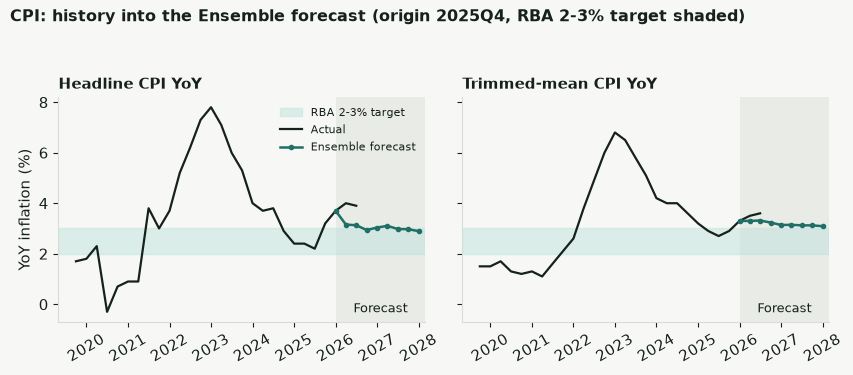

In [2]:
hist = pd.read_csv(TABLEAU / "historical_indicators.csv")
fc = pd.read_csv(TABLEAU / "forecast.csv")
fc_ens = fc[fc["model_family"] == "ensemble"].copy()
origin = fc_ens["forecast_origin"].iloc[0]

panels = [
    ("cpi_yoy", "Headline", "Headline CPI YoY"),
    ("trimmed_mean_cpi_yoy", "Trimmed mean", "Trimmed-mean CPI YoY"),
]

fig, axes = plt.subplots(1, 2, figsize=(8.6, 3.8), sharey=True)
for ax, (variable, target_label, title) in zip(axes, panels):
    h = hist[hist["variable"] == variable].sort_values("quarter").tail(28).copy()
    h["quarter_date"] = pd.PeriodIndex(h["quarter"], freq="Q").to_timestamp(how="end")
    f = fc_ens[fc_ens["target"] == target_label].sort_values("horizon").copy()
    f["quarter_date"] = pd.PeriodIndex(f["quarter"], freq="Q").to_timestamp(how="end")

    origin_row = h[h["quarter"] == origin].iloc[0]
    # forecast period: light grey at full plot height, from the origin to the right-hand edge
    x_origin, x_end = origin_row["quarter_date"], f["quarter_date"].max() + pd.Timedelta(days=60)
    ax.axvspan(x_origin, x_end, color=GRID, alpha=0.45, zorder=0, linewidth=0)
    ax.text(x_origin + (x_end - x_origin) / 2, 0.03, "Forecast", transform=ax.get_xaxis_transform(),
            ha="center", va="bottom", fontsize=9, color=INK)
    # RBA 2-3% target band, across the whole plot and drawn over the grey where they overlap
    ax.axhspan(2, 3, color=ACCENT_SOFT, alpha=0.5, zorder=1, label="RBA 2-3% target")
    ax.plot(h["quarter_date"], h["value"], color=INK, linewidth=1.6, label="Actual")
    fx = pd.concat([pd.Series([origin_row["quarter_date"]]), f["quarter_date"]], ignore_index=True)
    fy = pd.concat([pd.Series([origin_row["value"]]), f["forecast"]], ignore_index=True)
    ax.plot(fx, fy, color=ACCENT, linewidth=1.8, marker="o", markersize=3, label="Ensemble forecast")
    ax.set_xlim(right=x_end)

    ax.set_title(title, loc="left", fontsize=11, fontweight="bold")
    ax.tick_params(axis="x", rotation=30)
    ax.grid(False)

axes[0].set_ylabel("YoY inflation (%)")
axes[0].legend(frameon=False, fontsize=8, loc="upper right")
fig.suptitle(f"CPI: history into the Ensemble forecast (origin {origin}, RBA 2-3% target shaded)",
             x=0.01, ha="left", fontsize=11.5, fontweight="bold")
fig.tight_layout(rect=(0, 0, 1, 0.93))
plt.show()

The black line is inflation so far, and the teal line is the Ensemble's forecast from the end of 2025, set against the RBA's 2 to 3% target band. The Ensemble expects headline inflation of about 3.15% next quarter, easing to about 2.9% two years out. For trimmed-mean CPI it's about 3.3%, easing to about 3.1%. The ranges around these are wide, though: for headline CPI next quarter, the 80% range runs from roughly 1.2% to 6.0%.

```{admonition} Note
:class: note
Actual inflation keeps arriving as the ABS releases new data. It'll be used to check how the forecast is tracking, not to retrain the pinned model.
```

**How accurate is it, and how sure is it?** Each marker below is one model. Further left means smaller errors. The horizontal line marks the 80% target, and a marker sitting on it means the model's 80% ranges caught the actual result 80% of the time.

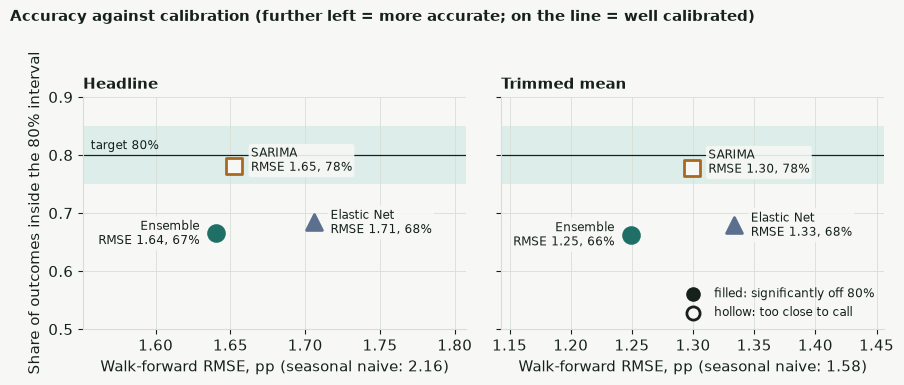

In [2]:
mc = pd.read_csv(TABLEAU / "model_comparison.csv")
cov = pd.read_csv(TABLEAU / "model_interval_coverage.csv")
summary = mc.merge(cov[["target", "model", "empirical_coverage", "significantly_miscalibrated"]],
                   on=["target", "model"], how="left")

names = {"sarima": "SARIMA", "elastic_net": "Elastic Net", "ensemble": "Ensemble"}
style = {"sarima": (HIGHLIGHT, "s"), "elastic_net": (BLUE, "^"), "ensemble": (ACCENT, "o")}
label_offset = {"sarima": (12, 4, "left"), "elastic_net": (12, 0, "left"), "ensemble": (-12, 0, "right")}

fig, axes = plt.subplots(1, 2, figsize=(9.0, 3.9), sharey=True)
for ax, target in zip(axes, ["Headline", "Trimmed mean"]):
    sub = summary[summary["target"] == target]
    naive = sub[sub["model"] == "seasonal_naive"]["rmse"].iloc[0]
    fitted = sub[sub["model"] != "seasonal_naive"]
    ax.axhspan(0.75, 0.85, color=ACCENT_SOFT, alpha=0.45, linewidth=0)
    ax.axhline(0.8, color=INK, linewidth=0.9)
    for _, r in fitted.iterrows():
        color, marker = style[r["model"]]
        off = bool(r["significantly_miscalibrated"])
        ax.scatter(r["rmse"], r["empirical_coverage"], s=130, marker=marker, color=color if off else PAPER,
                   edgecolor=color, linewidth=2.0, zorder=3)
        dx, dy, ha = label_offset[r["model"]]
        ax.annotate(f"{names[r['model']]}\nRMSE {r['rmse']:.2f}, {r['empirical_coverage'] * 100:.0f}%",
                    (r["rmse"], r["empirical_coverage"]), xytext=(dx, dy), textcoords="offset points",
                    ha=ha, va="center", fontsize=8.5,
                    bbox=dict(boxstyle="round,pad=0.2", facecolor=PAPER, edgecolor="none", alpha=0.9))
    span = fitted["rmse"].max() - fitted["rmse"].min()
    ax.set_xlim(fitted["rmse"].min() - 0.9 * span - 0.03, fitted["rmse"].max() + 1.1 * span + 0.03)
    ax.set_title(target, loc="left", fontsize=11, fontweight="bold")
    ax.set_xlabel(f"Walk-forward RMSE, pp (seasonal naive: {naive:.2f})")
    ax.set_ylim(0.5, 0.9)
axes[0].set_ylabel("Share of outcomes inside the 80% interval")
axes[0].text(0.02, 0.805, "target 80%", transform=axes[0].get_yaxis_transform(), fontsize=8.3, va="bottom")
axes[1].scatter([], [], s=90, color=INK, label="filled: significantly off 80%")
axes[1].scatter([], [], s=90, facecolor=PAPER, edgecolor=INK, linewidth=2.0, label="hollow: too close to call")
axes[1].legend(frameon=False, fontsize=8.3, loc="lower right")
fig.suptitle("Accuracy against calibration (further left = more accurate; on the line = well calibrated)",
             x=0.01, ha="left", fontsize=11, fontweight="bold")
fig.tight_layout(rect=(0, 0, 1, 0.93))
plt.show()

**How far to trust it.** The Ensemble has the lowest error on both measures, which is a real but modest gain from combining models. The catch is the forecast ranges. They're meant to contain the actual result 80% of the time. SARIMA's come close (about 78%), but Elastic Net's and the Ensemble's only cover about two-thirds. They do worst through the 2020 to 2023 inflation surge, when errors jumped several-fold. The ranges are widened using only past errors, so they follow a shock instead of seeing it coming. For anyone pricing interest rate risk, an overconfident range is the failure that would hurt most, which is why it's shown here and not just the point forecast.

:::{dropdown} How to read the markers
A filled marker means the coverage is statistically different from 80% (an exact binomial test at the 5% level, over this many forecasts). A hollow marker means it's too close to call. SARIMA's 78% is below 80% but hollow, because a gap that small is within what chance alone would produce.
:::

**Which model when.** Pooled over every horizon, the Ensemble wins. Split by how far ahead you're looking and the picture changes. SARIMA is the most accurate for the next one to three quarters (for headline CPI one quarter ahead, its typical error is 0.60 points against the Ensemble's 0.70), while from five quarters out Elastic Net or the Ensemble takes over. The dashed line is the naive benchmark.

{glue:}`/05_evaluation.ipynb::rmse_by_horizon_fig`

**How does it compare with the RBA's own forecast?** A fair comparison needed some care. The RBA forecasts the non-seasonally-adjusted rate and publishes no trimmed-mean forecast, so this is headline CPI only, with each forecaster scored against its own version of the actual result. On the same 424 forecasts (53 forecast dates, one to eight quarters ahead), the RBA's typical error is 1.69 percentage points, against 1.64 for the Ensemble, 1.65 for SARIMA and 1.71 for Elastic Net.

{glue:}`/05_evaluation.ipynb::rba_benchmark_fig`

On the right, each bar is the plausible range for the gap between a model and the RBA (a 95% range, found by resampling the forecast dates). Every bar crosses zero, so none of the gaps can be called real. The fair reading is that **the models are comparable to the RBA's forecast, not demonstrably better or worse.** Two things lean in the models' favour: they're scored on revised history instead of the numbers as first released, and the Ensemble's blend weights come from the same sample it's scored on. It's also a small sample.

*Full method: [§5 Evaluation](05_evaluation), and [Appendix §14](appendix_eda/14_rba_forecast_benchmark) for how the RBA's forecasts were lined up with ours.*

### 2. What will the RBA do next?

**What we built:** seven different ways of predicting the same cut, hold or hike decision: a simple threshold rule, two versions of the Taylor rule, ordered logit and probit, a Frank-Hall ordinal XGBoost model, and a majority vote of four of them.

*Full method: [§4.6 RBA Policy Classifier](04_modeling/46_rba_classifier).*

Forecast origin 2025Q4 -> target 2026Q1: the reportable call is 'hike' (threshold).


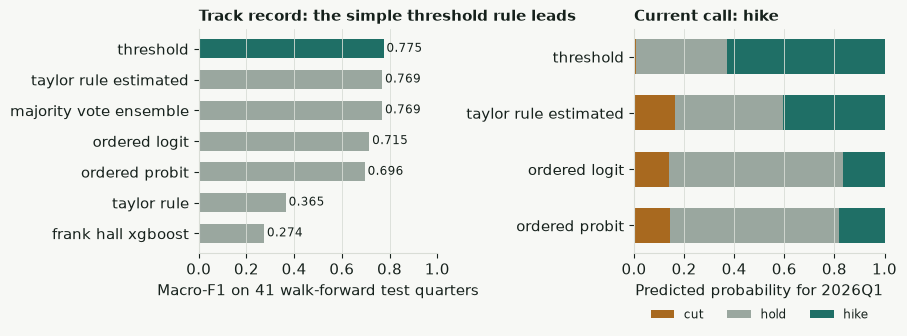

In [2]:
rba = pd.read_csv(TABLEAU / "rba_action.csv")
call = rba.iloc[0]
print(f"Forecast origin {call['forecast_origin']} -> target {call['target_quarter']}: "
      f"the reportable call is '{call['reportable_action']}' ({call['reportable_model']}).")

lines = (PROJECT_ROOT / "reports/rba_classifier_evaluation.md").read_text().splitlines()
start = next(i for i, l in enumerate(lines) if l.startswith("| model") and "macro_f1" in l)
rows = []
for l in lines[start:]:
    if not l.startswith("|"):
        break
    rows.append(l)
header = [c.strip() for c in rows[0].strip("|").split("|")]
data = [[c.strip() for c in r.strip("|").split("|")] for r in rows[2:]]
macro_f1 = (pd.DataFrame(data, columns=header).astype({"macro_f1": float, "accuracy": float, "n": int})
            .sort_values("macro_f1").reset_index(drop=True))
probs = rba.dropna(subset=["p_cut"]).set_index("model")[["p_cut", "p_hold", "p_hike"]].iloc[::-1]

fig, (a, b) = plt.subplots(1, 2, figsize=(9.2, 3.6), gridspec_kw={"width_ratios": [1, 1.05]})
colors = [ACCENT if m == call["reportable_model"] else MUTED for m in macro_f1["model"]]
a.barh(macro_f1["model"].str.replace("_", " "), macro_f1["macro_f1"], color=colors, height=0.62)
for y, v in enumerate(macro_f1["macro_f1"]):
    a.text(v + 0.012, y, f"{v:.3f}", va="center", fontsize=8.5)
a.set_xlim(0, 1)
a.set_xlabel("Macro-F1 on 41 walk-forward test quarters")
a.set_title("Track record: the simple threshold rule leads", loc="left", fontsize=10.5, fontweight="bold")
a.grid(axis="y", visible=False)

b.barh(probs.index.str.replace("_", " "), probs["p_cut"], color=HIGHLIGHT, height=0.62, label="cut")
b.barh(probs.index.str.replace("_", " "), probs["p_hold"], left=probs["p_cut"], color=MUTED, height=0.62, label="hold")
b.barh(probs.index.str.replace("_", " "), probs["p_hike"], left=probs["p_cut"] + probs["p_hold"], color=ACCENT,
       height=0.62, label="hike")
b.set_xlim(0, 1)
b.set_xlabel(f"Predicted probability for {call['target_quarter']}")
b.set_title(f"Current call: {call['reportable_action']}", loc="left", fontsize=10.5, fontweight="bold")
b.legend(frameon=False, ncol=3, fontsize=8.5, loc="upper center", bbox_to_anchor=(0.5, -0.2))
b.grid(axis="y", visible=False)
fig.tight_layout()
plt.show()
glue("rba_models_fig", fig, display=False)

The left chart scores each approach on how well it matched 41 past RBA decisions (higher is better). The right chart shows what the models that give probabilities expect for the next quarter.

**What it says.** The simple threshold rule ("is the forecast above or below the RBA's 2 to 3% band?") scored best, and it's the one the project reports. For 2026Q1 it says *hike*, at about 63% probability. But the headline forecast is only 3.15%, barely over the 3% line, and none of the other models agree: five say hold and one says cut.

**How far to trust it.** The threshold rule is the reportable model, but its lead over ordered logit, ordered probit and the majority vote isn't statistically clear. The honest claim is "a simple, transparent rule holds its own against more complex classifiers", not "we built a better RBA-prediction model". It's also a comparison on historical decisions, not a live, validated track record.

:::{dropdown} The statistics behind that
The macro-F1 gaps were resampled with a paired bootstrap, and the 95% intervals against those three models cross zero. [§4.6](04_modeling/46_rba_classifier) has the full comparison.
:::

### 3. How big could loan losses get?

**What we built:** an illustrative estimate of a bank's 12-month expected credit loss (ECL, the money it expects to lose on loans that go bad), following the AASB 9 accounting standard. It starts from NAB's own disclosed probability of default (from its Pillar 3 report, Table CR6) and stresses it using how sensitive defaults are to unemployment, with coefficients from a published RBA research paper. It also uses NAB's own disclosed loss given default (how much of a defaulted loan is lost) and exposure at default (how much is owed at that point), plus an RBA-sourced discount rate. Then it blends the downside, base and upside scenarios using NAB's own disclosed probability weights.

*Full method: [§4.7 Credit Stress](04_modeling/47_credit_stress); the unemployment scenarios come from [§4.4 SVAR](04_modeling/44_svar).*

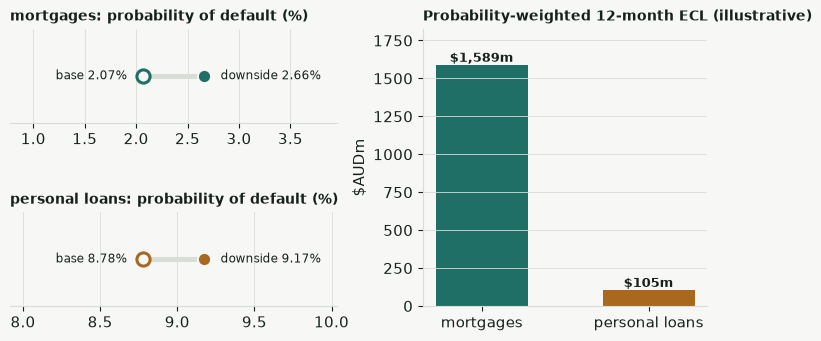

In [5]:
credit = pd.read_csv(TABLEAU / "credit_stress.csv")
segments = [("mortgages", ACCENT), ("personal_loans", HIGHLIGHT)]

fig = plt.figure(figsize=(9.0, 3.6))
gs = fig.add_gridspec(2, 2, width_ratios=[1.15, 1], hspace=0.95, wspace=0.28)
for row, (seg, color) in enumerate(segments):
    a = fig.add_subplot(gs[row, 0])
    down = credit[(credit["segment"] == seg) & (credit["scenario"] == "downside")].iloc[0]
    lo, hi = down["pd_base"] * 100, down["pd_stressed"] * 100
    a.plot([lo, hi], [0, 0], color=GRID, linewidth=3.5, zorder=1)
    a.scatter(lo, 0, s=90, facecolor=PAPER, edgecolor=color, linewidth=2.2, zorder=3)
    a.scatter(hi, 0, s=90, color=color, edgecolor=PAPER, linewidth=1.4, zorder=3)
    a.annotate(f"base {lo:.2f}%", (lo, 0), xytext=(-12, 0), textcoords="offset points", ha="right", va="center", fontsize=8.8)
    a.annotate(f"downside {hi:.2f}%", (hi, 0), xytext=(12, 0), textcoords="offset points", ha="left", va="center", fontsize=8.8)
    pad = (hi - lo) * 2.2
    a.set_xlim(lo - pad, hi + pad)
    a.set_ylim(-1, 1)
    a.set_yticks([])
    a.set_title(f"{seg.replace('_', ' ')}: probability of default (%)", loc="left", fontsize=10, fontweight="bold")
    a.grid(axis="y", visible=False)
    a.spines["left"].set_visible(False)

b = fig.add_subplot(gs[:, 1])
weighted = credit.drop_duplicates("segment").set_index("segment")["ecl_aud_m_12m_probability_weighted"]
b.bar([s.replace("_", " ") for s, _ in segments], [weighted[s] for s, _ in segments], color=[c for _, c in segments], width=0.55)
for x, (s, _) in enumerate(segments):
    b.text(x, weighted[s], f"${weighted[s]:,.0f}m", ha="center", va="bottom", fontsize=9.5, fontweight="bold")
b.set_ylim(0, weighted.max() * 1.15)
b.set_ylabel("$AUDm")
b.set_title("Probability-weighted 12-month ECL (illustrative)", loc="left", fontsize=10, fontweight="bold")
b.grid(axis="x", visible=False)
plt.show()

**How far to trust it, and the one to be most careful with.** This figure is **not** comparable to NAB's real provision. It's bigger than the real thing for an explainable reason, not an alarming one: it's a 12-month, Stage 1-only calculation with no staging logic, applied to the full exposure rather than a genuine Stage 1 subset. That makes it inflated compared with a real provision by design. It isn't a lower bound on NAB's real credit loss, or any kind of estimate of it, and it's not for actual credit or regulatory decisions.

:::{dropdown} The numbers behind that
NAB's real Stage 1 provision was \$646 million of a \$6,165 million Group total (roughly 10.5%). This project's illustrative mortgages figure is larger than that, and larger than NAB's real total (all-stage) Housing provision of \$1.296 billion.
:::

### What if something shifts?

The SVAR supplies the unemployment scenarios that Credit Stress uses directly, and it feeds the "what if" shocks to CPI in the Scenario Engine. Three of the four shock channels behave the way you'd expect: unemployment up means inflation down, and commodity prices up or inflation expectations up means inflation up. The cash-rate channel shows a well-known quirk called the "price puzzle". After a rate rise, the model first shows prices *rising*, because the RBA tends to raise rates when it already sees inflation building that the model can't observe. It's a known artifact of this kind of model, not a bug. The bigger caution is that both underlying VAR systems still fail their own residual diagnostics (whiteness and normality), so everything built on the SVAR, including every Scenario Engine output, is illustrative, not causal.

*Full method: [§4.4 SVAR](04_modeling/44_svar), [§4.5 Scenario Engine](04_modeling/45_scenario_engine).*

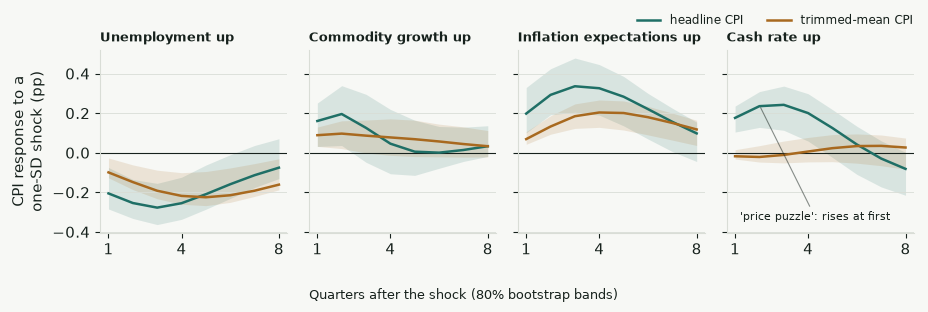

In [2]:
irf = pd.read_csv(TABLEAU / "svar_irf.csv")
irf = irf[irf["response"] == irf["target"]]
shocks = [("unemployment_rate", "Unemployment up"), ("commodity_growth", "Commodity growth up"),
          ("inflation_expectations_business", "Inflation expectations up"), ("cash_rate", "Cash rate up")]
systems = [("System A", "headline CPI", ACCENT), ("System B", "trimmed-mean CPI", HIGHLIGHT)]

fig, axes = plt.subplots(1, 4, figsize=(9.4, 2.9), sharex=True, sharey=True)
for ax, (shock, title) in zip(axes, shocks):
    ax.axhline(0, color=INK, linewidth=0.8)
    for system, label, color in systems:
        s = irf[(irf["system"] == system) & (irf["shock"] == shock)].sort_values("horizon")
        ax.fill_between(s["horizon"], s["lower"], s["upper"], color=color, alpha=0.14, linewidth=0)
        ax.plot(s["horizon"], s["irf"], color=color, linewidth=1.8, label=label)
    ax.set_title(title, loc="left", fontsize=9.3, fontweight="bold")
    ax.set_xticks([1, 4, 8])
    ax.grid(axis="x", visible=False)
axes[0].set_ylabel("CPI response to a\none-SD shock (pp)")
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, frameon=False, fontsize=8.5, loc="upper right", ncol=2, bbox_to_anchor=(0.99, 1.04))
axes[3].annotate("'price puzzle': rises at first", (2, 0.24), xytext=(1.2, -0.34), fontsize=8, ha="left",
                 bbox=dict(boxstyle="round,pad=0.2", facecolor=PAPER, edgecolor="none", alpha=0.9),
                 arrowprops=dict(arrowstyle="-", color=INK, alpha=0.5, lw=0.8))
fig.supxlabel("Quarters after the shock (80% bootstrap bands)", fontsize=9)
fig.tight_layout()
plt.show()
glue("irf_channels_fig", fig, display=False)

### How far to trust all this

The caveats from above, in one place:

- **It's a demo, not a production system.** Nothing here has been checked against outcomes beyond what NAB and the RBA have already published.
- **The forecast ranges are too narrow.** Elastic Net's and the Ensemble's 80% ranges caught the actual result only about two-thirds of the time.
- **The models are comparable to the RBA, not better.** The gap to the RBA's own forecast is too small to call.
- **The data is revised history.** The models were tested on revised numbers, not the figures as first published, and the Ensemble's blend weights come from the sample it's scored on. Both lean in the models' favour.
- **The RBA call is a comparison exercise.** The threshold rule's lead over fancier models isn't statistically clear, and it's tested on historical decisions.
- **The loan-loss figure is illustrative.** It's bigger than a real provision by design.
- **The what-if layer is illustrative.** Both SVAR systems fail their own diagnostics, and the cash-rate channel shows the price puzzle.
- **The samples are small.** The forecast comparison uses 53 forecast dates, and the RBA classifier is scored on 41 quarters.

### What's built, and what's live

The forecast API runs on Google Cloud Run (last verified live on 29 August 2026) and serves the headline, trimmed-mean and scenario forecasts. The RBA-decision and credit-stress endpoints work locally but aren't in the deployed version yet. The Streamlit app runs locally and calls the API. [§6 Deployment](06_deployment) has the details.

### Grounded in real disclosures

Every business figure above is sourced, not assumed. NAB's own FY2025 disclosures (its Pillar 3 report and Annual Report) supply the default, loss, exposure and scenario-weighting inputs, and a peer-reviewed RBA research paper supplies the unemployment sensitivity used to stress them. The diagram shows where each input comes from.

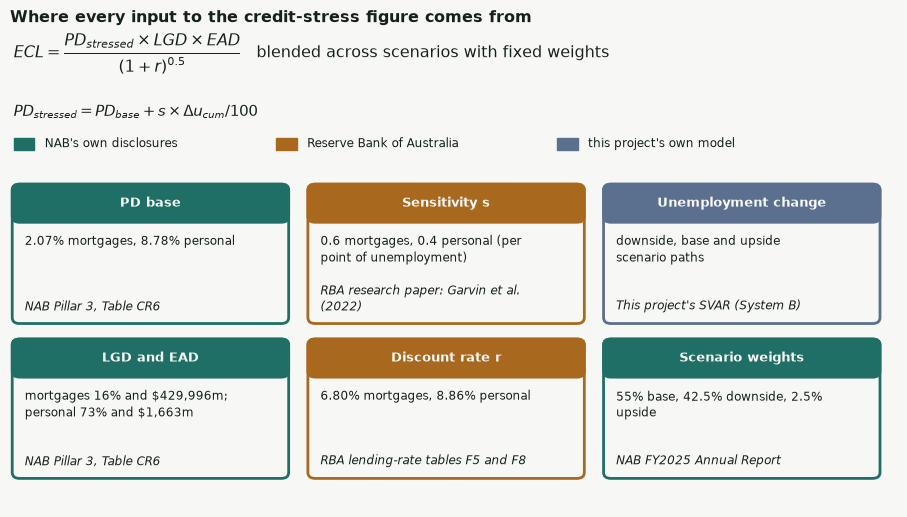

In [3]:
import textwrap
from matplotlib.patches import FancyBboxPatch

credit = pd.read_csv(TABLEAU / "credit_stress.csv")
seg = credit.drop_duplicates("segment").set_index("segment")
m, p = seg.loc["mortgages"], seg.loc["personal_loans"]
w = credit[credit["segment"] == "mortgages"].set_index("scenario")["probability_weight"]

NAB, RBA, SVAR = ACCENT, HIGHLIGHT, BLUE
inputs = [   # (term, values, source, colour)
    ("PD base", f"{m['pd_base'] * 100:.2f}% mortgages, {p['pd_base'] * 100:.2f}% personal", "NAB Pillar 3, Table CR6", NAB),
    ("Sensitivity s", f"{m['ur_sensitivity']:.1f} mortgages, {p['ur_sensitivity']:.1f} personal (per point of unemployment)",
     "RBA research paper: Garvin et al. (2022)", RBA),
    ("Unemployment change", "downside, base and upside scenario paths", "This project's SVAR (System B)", SVAR),
    ("LGD and EAD", f"mortgages {m['lgd'] * 100:.0f}% and ${m['ead_aud_m']:,.0f}m; personal {p['lgd'] * 100:.0f}% and ${p['ead_aud_m']:,.0f}m",
     "NAB Pillar 3, Table CR6", NAB),
    ("Discount rate r", f"{m['discount_rate'] * 100:.2f}% mortgages, {p['discount_rate'] * 100:.2f}% personal",
     "RBA lending-rate tables F5 and F8", RBA),
    ("Scenario weights", f"{w['base'] * 100:g}% base, {w['downside'] * 100:g}% downside, {w['upside'] * 100:g}% upside",
     "NAB FY2025 Annual Report", NAB),
]
fig, ax = plt.subplots(figsize=(9.2, 5.3))
ax.set_xlim(0, 12)
ax.set_ylim(0, 8)
ax.axis("off")
ax.text(0.05, 7.95, r"$ECL = \dfrac{PD_{stressed} \times LGD \times EAD}{(1+r)^{0.5}}$   blended across scenarios with fixed weights",
        fontsize=11.5, va="top")
ax.text(0.05, 6.75, r"$PD_{stressed} = PD_{base} + s \times \Delta u_{cum} / 100$", fontsize=10.5, va="top")
for x, color, label in [(0.05, NAB, "NAB's own disclosures"), (3.6, RBA, "Reserve Bank of Australia"), (7.4, SVAR, "this project's own model")]:
    ax.add_patch(plt.Rectangle((x, 6.0), 0.28, 0.2, facecolor=color, edgecolor=color))
    ax.text(x + 0.42, 6.1, label, va="center", fontsize=8.8)
bw, bh, gx, gy = 3.7, 2.3, 0.3, 0.3
for i, (term, values, source, color) in enumerate(inputs):
    r, c = divmod(i, 3)
    x, y = 0.05 + c * (bw + gx), 5.4 - bh - r * (bh + gy) + 0.0
    y = 5.4 - (r + 1) * bh - r * gy
    ax.add_patch(FancyBboxPatch((x, y), bw, bh, boxstyle="round,pad=0.02,rounding_size=0.1", facecolor=PAPER,
                                edgecolor=color, linewidth=2.0))
    ax.add_patch(FancyBboxPatch((x, y + bh - 0.6), bw, 0.6, boxstyle="round,pad=0.02,rounding_size=0.1",
                                facecolor=color, edgecolor=color, linewidth=2.0))
    ax.text(x + bw / 2, y + bh - 0.3, term, ha="center", va="center", fontsize=9.5, fontweight="bold", color=PAPER)
    ax.text(x + 0.15, y + bh - 0.8, "\n".join(textwrap.wrap(values, 33)), ha="left", va="top", fontsize=8.6, linespacing=1.4)
    ax.text(x + 0.15, y + 0.15, "\n".join(textwrap.wrap(source, 36)), ha="left", va="bottom", fontsize=8.3,
            style="italic", linespacing=1.3)
ax.set_title("Where every input to the credit-stress figure comes from", loc="left", fontsize=11.5, fontweight="bold")
fig.tight_layout()
plt.show()
glue("input_sources_fig", fig, display=False)

### Read on

The rest of the book walks through the full CRISP-DM pipeline behind these numbers, and every equation is followed by a plain-English explanation. Start with [Business Understanding](01_business_understanding), or jump straight to a model: [SARIMA](04_modeling/41_sarima), [Elastic Net](04_modeling/42_elastic_net) and [Ensemble](04_modeling/43_ensemble); [SVAR](04_modeling/44_svar) and the [Scenario Engine](04_modeling/45_scenario_engine); the [RBA Policy Classifier](04_modeling/46_rba_classifier); or [Credit Stress](04_modeling/47_credit_stress). The comparison against the RBA's forecast is in [§5 Evaluation](05_evaluation).

### References

Australian Prudential Regulation Authority. (2024). *Prudential standard APS 117: Capital
adequacy — interest rate risk in the banking book* (Determination No. 5 of 2024).
https://www.legislation.gov.au/F2024L01182/latest/text

Garvin, N., Kurian, S., Major, M., & Norman, D. (2022). *Macrofinancial stress testing on
Australian banks* (Research Discussion Paper No. RDP 2022-03). Reserve Bank of Australia.
https://www.rba.gov.au/publications/rdp/2022/2022-03.html